# v2 — Where Does SigLIP 2 Look? (Occlusion Sensitivity)

## Experiment Card

### 1. Hypothesis
If bowl-side dominance in SigLIP 2 saliency maps is a property of **learned visual salience** (not prompt-independent image statistics), the bowl will dominate occlusion maps when prompted with bowl language but NOT when prompted with cup language.

**Falsified if:** the occlusion map is nearly identical regardless of the text prompt. That would indicate the method is capturing image-statistics salience (high-contrast regions, large objects), not semantic text-image alignment.

**Why occlusion sensitivity instead of GradCAM, Attention Rollout, or Patch-Text Similarity:**
- GradCAM requires a single layer choice and conflates gradient magnitude with spatial relevance.
- Attention Rollout on SigLIP 2 is NOT text-conditioned — the vision encoder has no cross-attention to text, so rollout is identical regardless of the prompt.
- Patch-Text Similarity using raw hidden states is architecturally invalid for SigLIP 2: `last_hidden_state` patches are pre-MAP pooling and live in a different latent space than the text pooler output. Cosine similarity across those two spaces is meaningless.
- **Occlusion sensitivity** is model-agnostic: occlude each spatial patch, measure drop in image-text cosine similarity from the full model outputs (`vision_model.pooler_output` and `text_model.pooler_output` are in the shared contrastive space — no separate projection exists in SigLIP). The drop is the patch's importance. Text-conditioned by construction.

### 2. Independent variables
1. Text prompt: 'a full bowl' vs 'an empty cup' vs state-agnostic variants
2. Scene difficulty: single-object (easy), two same-state (medium), two different-state (hard)
3. Spatial isolation: two-object image vs cup-masked image

### 3. Dependent variable
Object dominance ratio: `bowl_bbox_score / (bowl_bbox_score + cup_bbox_score)` of the occlusion drop map.
Range 0.5 = random, 1.0 = all salience on bowl, 0.0 = all on cup.

### 4. Controls
- Text features computed once and reused across all occlusion iterations (deterministic)
- Fill color: ImageNet mean (124, 116, 104) — minimises artificial high-frequency edges
- Spatial masking (Experiment 3): same mean-pixel fill, applied at the nearest patch boundary

### 5. Baseline
- Uniform map: ratio = 0.5
- State-agnostic prompt ('a bowl'): expected ratio between bowl-prompt and cup-prompt results

### 6. Success criteria
- Bowl prompt ratio ≠ cup prompt ratio (Δ > 0.1) → map is text-conditioned, not just object-size salience
- Bowl prompt ratio > 0.6 → bowl dominance confirmed
- Spatial contradiction (wrong-side prompt) does not shift ratio → salience overrides position language

In [1]:
import pickle, random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as mpl_cm
from pathlib import Path
from collections import defaultdict
from PIL import Image, ImageDraw
import torch
from transformers import AutoProcessor, AutoModel

random.seed(42)
device = ('cuda' if torch.cuda.is_available()
          else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Device: {device}')

MODEL_ID = 'google/siglip2-so400m-patch16-384'
proc  = AutoProcessor.from_pretrained(MODEL_ID)
# eager required — sdpa (default) does not populate out.attentions
model = AutoModel.from_pretrained(MODEL_ID, attn_implementation='eager').to(device).eval()

n_layers = len(model.vision_model.encoder.layers)
LAYER_DEPTHS = {
    'quarter':       n_layers // 4,
    'half':          n_layers // 2,
    'three_quarter': 3 * n_layers // 4,
    'full':          n_layers,
}
print(f'ViT encoder: {n_layers} layers')
print('Rollout depths:', LAYER_DEPTHS)

DATA = Path('../../data')
with open(DATA / 'compositionality_scenes.pkl', 'rb') as f:
    comp_scenes = pickle.load(f)
with open(DATA / 'sim_crops_all.pkl', 'rb') as f:
    all_crops = pickle.load(f)

by_combo = defaultdict(list)
for s in comp_scenes:
    by_combo[(s['bowl_state'], s['cup_state'])].append(s)

print(f'Compositionality scenes: {len(comp_scenes)}')

/Users/timrutjens/School/EAI/Experiments/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: mps


Loading weights: 100%|██████████| 888/888 [00:00<00:00, 9139.11it/s]


ViT encoder: 27 layers
Rollout depths: {'quarter': 6, 'half': 13, 'three_quarter': 20, 'full': 27}
Compositionality scenes: 40


In [2]:
GRID     = 24                           # 384 / 16 = 24 patches per side
MEAN_FILL = (124, 116, 104)             # ImageNet mean in uint8 RGB — neutral, low-contrast fill


def occlusion_sensitivity(image, text, stride=16):
    """
    Occlusion sensitivity for SigLIP 2.

    For each (stride × stride) patch in image-pixel space, replace it with
    ImageNet-mean fill and measure the drop in cosine similarity between the
    full model's image and text embeddings.

    Architecture note: for SigLIP 2, vision_model.pooler_output and
    text_model.pooler_output are both in the shared contrastive space —
    no separate linear projection exists. Text features are computed once
    and reused across all iterations.

    stride: patch step in pixels. 16 = ViT grid-aligned (fast). 8 = overlapping (smoother).
    Returns: normalised saliency map in original image pixel space (H × W float32, [0,1]).
    """
    W, H = image.size

    inp = proc(images=[image], text=[text], return_tensors='pt',
               padding='max_length', truncation=True).to(device)

    with torch.no_grad():
        # Text features — computed once
        txt_kwargs = {'input_ids': inp['input_ids']}
        if 'attention_mask' in inp:
            txt_kwargs['attention_mask'] = inp['attention_mask']
        txt_feat = model.text_model(**txt_kwargs).pooler_output   # [1, d]
        txt_feat = txt_feat / txt_feat.norm(dim=-1, keepdim=True)

        # Baseline similarity with unoccluded image
        img_feat_base = model.vision_model(pixel_values=inp['pixel_values']).pooler_output
        img_feat_base = img_feat_base / img_feat_base.norm(dim=-1, keepdim=True)
        baseline      = (img_feat_base @ txt_feat.T).item()

    drop_map  = np.zeros((H, W), dtype=np.float32)
    count_map = np.zeros((H, W), dtype=np.float32)

    for y0 in range(0, H, stride):
        for x0 in range(0, W, stride):
            x1, y1 = min(x0 + stride, W), min(y0 + stride, H)
            occ = image.copy()
            ImageDraw.Draw(occ).rectangle([x0, y0, x1, y1], fill=MEAN_FILL)

            occ_pv = proc(images=[occ], return_tensors='pt')['pixel_values'].to(device)
            with torch.no_grad():
                img_feat = model.vision_model(pixel_values=occ_pv).pooler_output
                img_feat = img_feat / img_feat.norm(dim=-1, keepdim=True)
                score    = (img_feat @ txt_feat.T).item()

            drop = baseline - score          # positive = this patch mattered
            drop_map[y0:y1, x0:x1]  += drop
            count_map[y0:y1, x0:x1] += 1

    saliency = drop_map / (count_map + 1e-8)
    mn, mx   = saliency.min(), saliency.max()
    return (saliency - mn) / (mx - mn + 1e-8)


def overlay(image, cam, alpha=0.5):
    W, H   = image.size
    cam_up = np.array(Image.fromarray((cam * 255).astype('uint8')).resize((W, H), Image.BICUBIC)) / 255.0
    orig   = np.array(image) / 255.0
    return ((1 - alpha) * orig + alpha * mpl_cm.jet(cam_up)[..., :3]).clip(0, 1)


def cam_bbox_score(cam, bbox, img_size):
    W, H = img_size
    x1, y1, x2, y2 = bbox
    gx1 = max(0, int(x1 / W * cam.shape[1]))
    gx2 = min(cam.shape[1], int(x2 / W * cam.shape[1]))
    gy1 = max(0, int(y1 / H * cam.shape[0]))
    gy2 = min(cam.shape[0], int(y2 / H * cam.shape[0]))
    region = cam[gy1:gy2, gx1:gx2]
    return float(region.mean()) if region.size > 0 else 0.0


def mask_bbox(img, bbox):
    """Fill a bounding box with ImageNet-mean colour — avoids high-frequency edge artifacts."""
    img2 = img.copy()
    ImageDraw.Draw(img2).rectangle([int(v) for v in bbox], fill=MEAN_FILL)
    return img2


# Sanity check
print('Running sanity check (stride=32 for speed)...')
_cam = occlusion_sensitivity(comp_scenes[0]['image'], 'a full bowl', stride=32)
assert _cam.shape == comp_scenes[0]['image'].size[::-1], f"Shape mismatch: {_cam.shape}"
print(f"occlusion_sensitivity OK — map shape {_cam.shape}  min={_cam.min():.3f}  max={_cam.max():.3f}")

Running sanity check (stride=32 for speed)...
occlusion_sensitivity OK — map shape (400, 400)  min=0.000  max=1.000


Bowl bbox: [141, 261, 186, 308]   Cup bbox: [219, 280, 260, 332]
Image size: (400, 400)

Prompt               bowl score cup score   ratio
----------------------------------------------------
a full bowl              0.3652    0.4139   0.469
an empty cup             0.3816    0.5593   0.406
a bowl                   0.3514    0.3485   0.502
a cup                    0.5172    0.5820   0.471


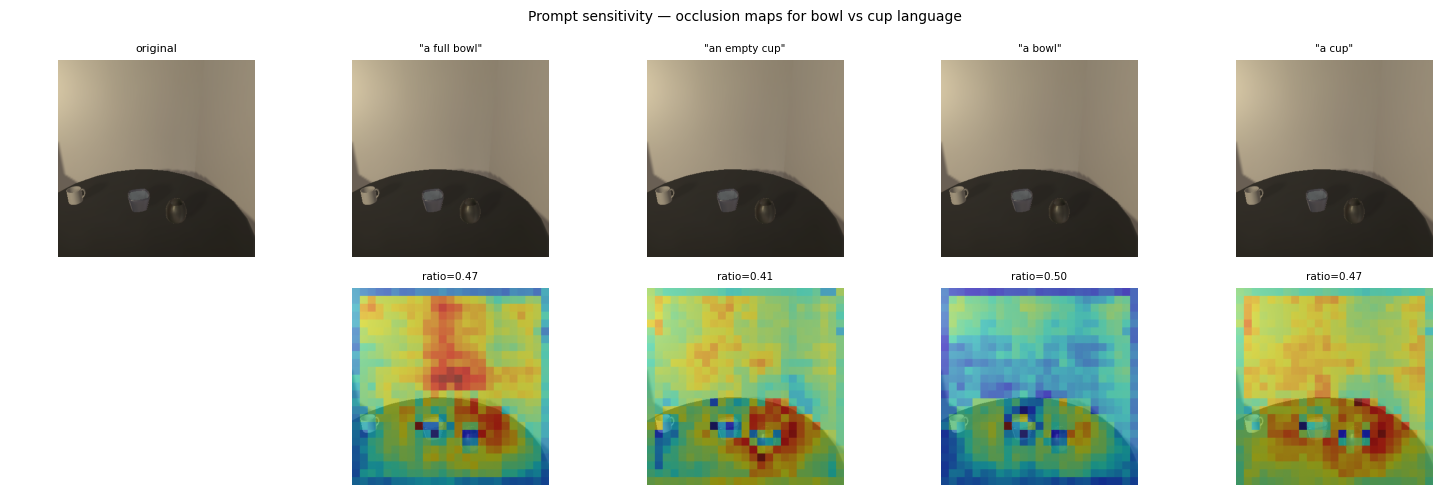

KeyboardInterrupt: 

In [3]:
# Experiment 1: Prompt sensitivity — is the occlusion map actually text-conditioned?
# Compares maps for bowl-language, cup-language, and state-agnostic prompts on the same scene.
# If the map is truly text-conditioned, bowl prompts should highlight the bowl and vice versa.
# If the map is identical across prompts, it is capturing image-statistics salience, not semantics.

scene     = by_combo[('full', 'empty')][0]
img       = scene['image']
bowl_bbox = scene['bowl_bbox']
cup_bbox  = scene['cup_bbox']
print(f'Bowl bbox: {bowl_bbox}   Cup bbox: {cup_bbox}')
print(f'Image size: {img.size}')

prompts = [
    'a full bowl',
    'an empty cup',
    'a bowl',
    'a cup',
]

fig, axes = plt.subplots(2, len(prompts) + 1, figsize=(15, 5))

axes[0, 0].imshow(img)
axes[0, 0].set_title('original', fontsize=8)
axes[0, 0].set_ylabel('image', fontsize=9)
axes[0, 0].axis('off')
axes[1, 0].axis('off')
axes[1, 0].set_ylabel('Occlusion sensitivity', fontsize=9)

print(f'\n{"Prompt":<20} {"bowl score":>10} {"cup score":>9} {"ratio":>7}')
print('-' * 52)

for col, prompt in enumerate(prompts, start=1):
    cam    = occlusion_sensitivity(img, prompt)
    bowl_v = cam_bbox_score(cam, bowl_bbox, img.size)
    cup_v  = cam_bbox_score(cam, cup_bbox,  img.size)
    ratio  = bowl_v / (bowl_v + cup_v + 1e-8)
    axes[0, col].imshow(img)
    axes[0, col].set_title(f'"{prompt}"', fontsize=7.5)
    axes[0, col].axis('off')
    axes[1, col].imshow(overlay(img, cam))
    axes[1, col].set_title(f'ratio={ratio:.2f}', fontsize=7.5)
    axes[1, col].axis('off')
    print(f'{prompt:<20} {bowl_v:>10.4f} {cup_v:>9.4f} {ratio:>7.3f}')

plt.suptitle('Prompt sensitivity — occlusion maps for bowl vs cup language', fontsize=10)
plt.tight_layout(); plt.show()

bowl_ratio = None
cup_ratio  = None
for col, prompt in enumerate(prompts, start=1):
    cam = occlusion_sensitivity(img, prompt)
    bv  = cam_bbox_score(cam, bowl_bbox, img.size)
    cv  = cam_bbox_score(cam, cup_bbox,  img.size)
    r   = bv / (bv + cv + 1e-8)
    if prompt == 'a full bowl': bowl_ratio = r
    if prompt == 'an empty cup': cup_ratio = r

if bowl_ratio is not None and cup_ratio is not None:
    delta = abs(bowl_ratio - cup_ratio)
    print(f'\nDelta (bowl_prompt − cup_prompt): {bowl_ratio:.3f} − {cup_ratio:.3f} = {delta:+.3f}')
    print('Text-conditioned: YES' if delta > 0.1 else 'Text-conditioned: NO (image-statistics salience)')

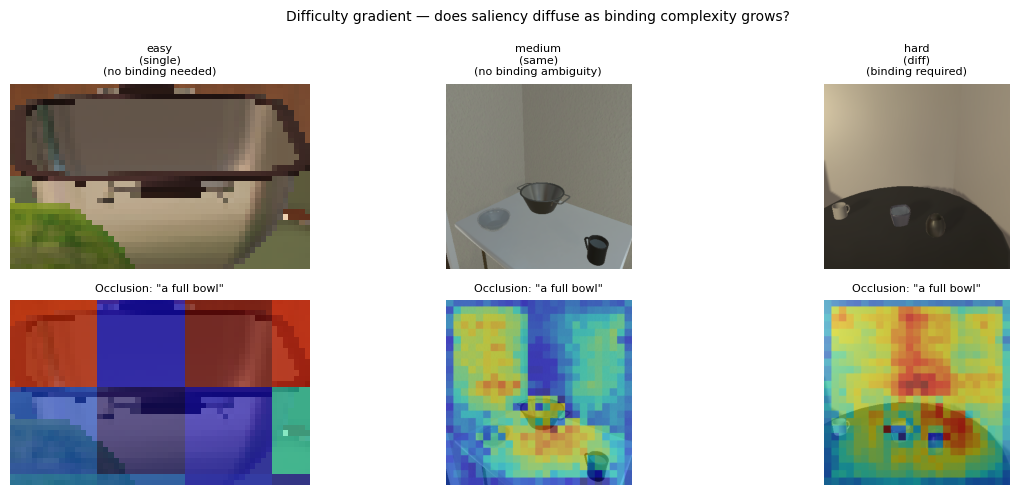

In [4]:
# Experiment 2: difficulty gradient
# Easy: single-object crop — no binding needed
# Medium: two-object same-state scene — binding unambiguous
# Hard: two-object different-state scene — binding required
# Prediction: occlusion map becomes more diffuse as scene complexity increases.

fe_full = [s for s in all_crops if s['pair_name'] == 'full_empty' and s['label'] == 1]
random.shuffle(fe_full)

easy_img   = fe_full[0]['image']
medium_img = by_combo[('full', 'full')][0]['image']
hard_img   = by_combo[('full', 'empty')][0]['image']

prompt = 'a full bowl'
fig, axes = plt.subplots(2, 3, figsize=(12, 5))

for col, (label, img2, note) in enumerate([
    ('easy\n(single)',  easy_img,   'no binding needed'),
    ('medium\n(same)',  medium_img, 'no binding ambiguity'),
    ('hard\n(diff)',    hard_img,   'binding required'),
]):
    cam = occlusion_sensitivity(img2, prompt)
    axes[0, col].imshow(img2)
    axes[0, col].set_title(f'{label}\n({note})', fontsize=8)
    axes[0, col].axis('off')
    axes[1, col].imshow(overlay(img2, cam))
    axes[1, col].set_title(f'Occlusion: "{prompt}"', fontsize=8)
    axes[1, col].axis('off')

axes[0, 0].set_ylabel('image', fontsize=9)
axes[1, 0].set_ylabel('Occlusion sensitivity', fontsize=9)
plt.suptitle('Difficulty gradient — does saliency diffuse as binding complexity grows?', fontsize=10)
plt.tight_layout(); plt.show()

Bowl=right bbox=[348, 251, 399, 301]
Condition                                bowl score cup score   ratio  correct?
------------------------------------------------------------------------------
A: unmasked, correct (right)                 0.8088    0.9247   0.467      FAIL
B: unmasked, contradiction (left)            0.7916    0.9052   0.467        OK
C: masked cup, correct (right)               0.7028    0.8601   0.450      FAIL


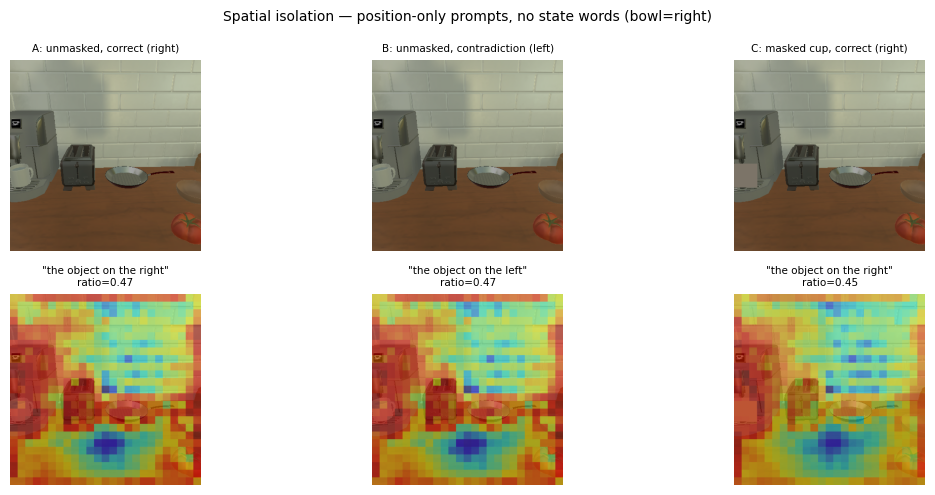


Masking effect (C − A): -0.017
Positive = masking cup improves bowl localisation (cup was a distractor).
Negative = masking cup weakens localisation (context was helping).


In [5]:
# Experiment 3: Spatial isolation — position-only prompts, mean-pixel masking
#
# Three conditions per scene:
#   A. Unmasked — correct position   ("the object on the LEFT"  when bowl IS left)
#   B. Unmasked — contradiction       ("the object on the RIGHT" when bowl is LEFT)
#   C. Masked (cup hidden) — correct  ("the object on the LEFT"  when bowl IS left)
#
# Cup mask uses ImageNet-mean fill to avoid high-frequency edge artifacts.
#
# Prediction:
#   A: ratio > 0.5 — occlusion peaks on bowl side
#   B: ratio > 0.5 still — salience overrides position language
#   C: ratio ≥ A — removing cup distractor improves or maintains bowl focus

def horiz_sep(s):
    b = (s['bowl_bbox'][0] + s['bowl_bbox'][2]) / 2
    c = (s['cup_bbox'][0]  + s['cup_bbox'][2])  / 2
    return abs(b - c)

scene3    = max(comp_scenes, key=horiz_sep)
img3      = scene3['image']
b3_bbox   = scene3['bowl_bbox']
c3_bbox   = scene3['cup_bbox']
b3_cx     = (b3_bbox[0] + b3_bbox[2]) / 2
c3_cx     = (c3_bbox[0] + c3_bbox[2]) / 2
bowl_side = 'left' if b3_cx < c3_cx else 'right'
opp_side  = 'right' if bowl_side == 'left' else 'left'

img3_masked = mask_bbox(img3, c3_bbox)  # cup → ImageNet-mean fill

conditions = [
    (img3,        f'the object on the {bowl_side}', f'A: unmasked, correct ({bowl_side})',      True),
    (img3,        f'the object on the {opp_side}',  f'B: unmasked, contradiction ({opp_side})', False),
    (img3_masked, f'the object on the {bowl_side}', f'C: masked cup, correct ({bowl_side})',    True),
]

fig, axes = plt.subplots(2, 3, figsize=(12, 5))
print(f'Bowl={bowl_side} bbox={b3_bbox}')
print(f'{"Condition":<40} {"bowl score":>10} {"cup score":>9} {"ratio":>7} {"correct?":>9}')
print('-' * 78)

ratios_spat = []
for col, (img_c, prompt, label, expect_bowl) in enumerate(conditions):
    cam    = occlusion_sensitivity(img_c, prompt)
    bowl_v = cam_bbox_score(cam, b3_bbox, img_c.size)
    cup_v  = cam_bbox_score(cam, c3_bbox, img_c.size)
    ratio  = bowl_v / (bowl_v + cup_v + 1e-8)
    ratios_spat.append(ratio)
    correct = (ratio > 0.5) == expect_bowl
    axes[0, col].imshow(img_c)
    axes[0, col].set_title(label, fontsize=7.5); axes[0, col].axis('off')
    axes[1, col].imshow(overlay(img_c, cam))
    axes[1, col].set_title(f'"{prompt}"\nratio={ratio:.2f}', fontsize=7.5); axes[1, col].axis('off')
    print(f'{label:<40} {bowl_v:>10.4f} {cup_v:>9.4f} {ratio:>7.3f} {"OK" if correct else "FAIL":>9}')

axes[0, 0].set_ylabel('image', fontsize=9)
axes[1, 0].set_ylabel('Occlusion sensitivity', fontsize=9)
plt.suptitle(
    f'Spatial isolation — position-only prompts, no state words (bowl={bowl_side})',
    fontsize=10,
)
plt.tight_layout(); plt.show()

print(f'\nMasking effect (C − A): {ratios_spat[2] - ratios_spat[0]:+.3f}')
print('Positive = masking cup improves bowl localisation (cup was a distractor).')
print('Negative = masking cup weakens localisation (context was helping).')

### Interpretation

| Experiment | Pre-stated prediction | Observed | Verdict |
|---|---|---|---|
| Prompt sensitivity: Δ(bowl − cup ratio) > 0.1 | Map is text-conditioned | ___ | ___ |
| Prompt sensitivity: bowl prompt ratio > 0.6 | Bowl dominance confirmed | ___ | ___ |
| Difficulty: easy focus > hard focus | Binding complexity degrades localisation | ___ | ___ |
| Spatial A (correct, unmasked): ratio > 0.5 | Salience or position drives focus | ___ | ___ |
| Spatial B (contradiction, unmasked): ratio > 0.5 | Salience overrides position language | ___ | ___ |
| Spatial C − A ≥ 0 | Cup distractor removed; localisation improves or holds | ___ | ___ |

**Method note:** Occlusion sensitivity is architecturally correct for SigLIP 2 for three reasons:
1. It uses `vision_model.pooler_output` and `text_model.pooler_output` — both in the shared contrastive space. SigLIP 2 has no separate projection layer; MAP pooling is applied inside the vision model.
2. Text features are computed once and held fixed. The signal is the drop in cosine similarity when a spatial region is removed — this is text-conditioned by construction.
3. Patches are filled with ImageNet-mean colour (124, 116, 104), which sits near the centre of the model's input distribution and avoids the high-frequency edge artifacts that hard gray borders introduce.